import required libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [33]:
data = pd.read_csv("C:\Tekworks\Day 15\customer_churn.csv")
data.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1


In [34]:
data.dtypes

age                        int64
income                   float64
credit_score             float64
transactions_month         int64
avg_purchase_value       float64
days_since_last_login      int64
tenure_months              int64
num_products               int64
gender                    object
region                    object
churn                      int64
dtype: object

In [35]:
# check the colnames
data.columns

Index(['age', 'income', 'credit_score', 'transactions_month',
       'avg_purchase_value', 'days_since_last_login', 'tenure_months',
       'num_products', 'gender', 'region', 'churn'],
      dtype='object')

In [36]:
# checking null values
data.isnull().sum()

age                       0
income                   49
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [37]:
#check the value count of the output column
data['churn'].value_counts()


churn
1    517
0    483
Name: count, dtype: int64

In [38]:
#check the categorical and numerical columns
categorical_cols = data.select_dtypes(include='object').columns
numerical_cols = data.select_dtypes(include=['int64','float64'])
categorical_cols
print("Numerical Columns:")
print(numerical_cols.columns)

print("Categorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['age', 'income', 'credit_score', 'transactions_month',
       'avg_purchase_value', 'days_since_last_login', 'tenure_months',
       'num_products', 'churn'],
      dtype='object')
Categorical Columns:
Index(['gender', 'region'], dtype='object')


In [39]:
# check summary
data.describe()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,churn
count,1000.00000,951.000000,950.000000,1000.000000,950.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,55354.417513,651.422837,29.842000,119.301574,182.155000,60.394000,3.129000,0.517000
std,14.99103,32708.500386,68.271995,5.453511,39.619144,104.205824,34.163166,1.410088,0.499961
min,18.00000,7271.860691,444.172796,15.000000,-7.068153,0.000000,1.000000,1.000000,0.000000
25%,31.00000,40959.853770,605.096009,26.000000,93.330104,88.000000,31.000000,2.000000,0.000000
50%,44.00000,51298.846812,650.746768,30.000000,119.585761,184.000000,61.000000,3.000000,1.000000
75%,56.00000,61285.465584,697.845647,33.000000,146.374081,273.250000,89.250000,4.000000,1.000000
max,69.00000,254852.478291,873.517530,49.000000,244.516408,364.000000,119.000000,5.000000,1.000000


Data Preprocessing

In [40]:
# handled the missing values in the dataset

data['income'].value_counts()



income
254852.478291    20
53051.954538      1
39677.744822      1
51883.646802      1
47403.922636      1
                 ..
43317.462179      1
73693.582186      1
42157.099593      1
43697.197744      1
44407.502719      1
Name: count, Length: 932, dtype: int64

In [41]:
# finding mean , median,mode of the income column
mean_income = data['income'].mean()
median_income = data['income'].median()
mode_income = data['income'].median()
print("Mean Income:", mean_income) 
print("Median Income:", median_income) 
print("Mode Income:", mode_income) 



Mean Income: 55354.41751318089
Median Income: 51298.8468120935
Mode Income: 51298.8468120935


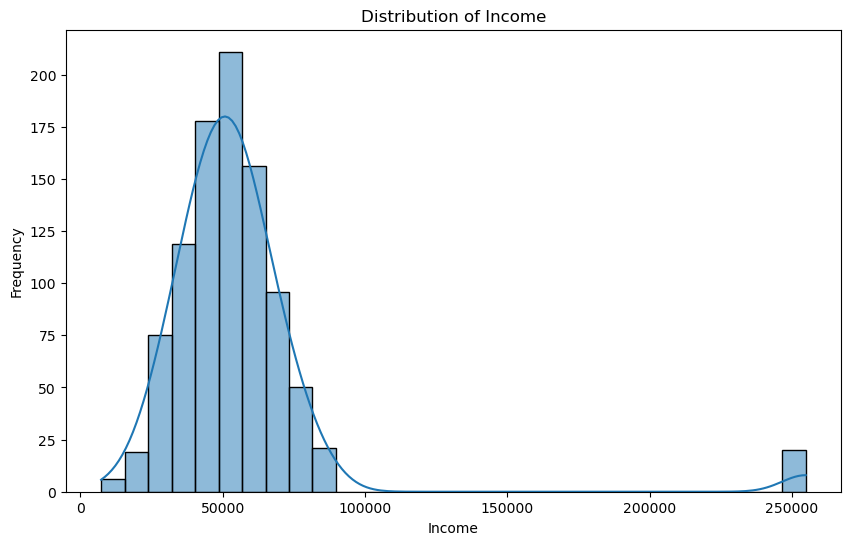

In [42]:

#distribution of income column
plt.figure(figsize=(10, 6))
sns.histplot(data['income'], bins=30, kde=True)
plt.title('Distribution of Income') 
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

In [43]:
# check the outlier ratio in the income column


Q1 = data['income'].quantile(0.25)
Q3 = data['income'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['income'] < lower) | (data['income'] > upper)]

outlier_ratio = len(outliers) / len(data)

print("Total Rows:", len(data))
print("Outliers:", len(outliers))
print("Outlier Ratio:", outlier_ratio)

Total Rows: 1000
Outliers: 23
Outlier Ratio: 0.023


In [44]:
# find the median of the income column after removing the outliers

Q1 = data['income'].quantile(0.25)
Q3 = data['income'].quantile(0.75)

IQR = Q3 - Q1

# Define bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove outliers
data_no_outliers = data[(data['income'] >= lower) & (data['income'] <= upper)]

# Find median after removing outliers
median_income = data_no_outliers['income'].median()

print("Median income after removing outliers:", median_income)


Median income after removing outliers: 50891.36602950997


In [45]:
#using round function to round the medium income to 6 decimal poinds
median_income=round(median_income, 6)
median_income

50891.36603

In [46]:
#fill the income column missing values with the median income
data['income'].fillna(median_income, inplace = True)

C:\Users\MAHIPALREDDY\AppData\Local\Temp\ipykernel_4980\2443858011.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['income'].fillna(median_income, inplace = True)


In [48]:
#check the missing values again
data.isnull().sum()

age                       0
income                    0
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

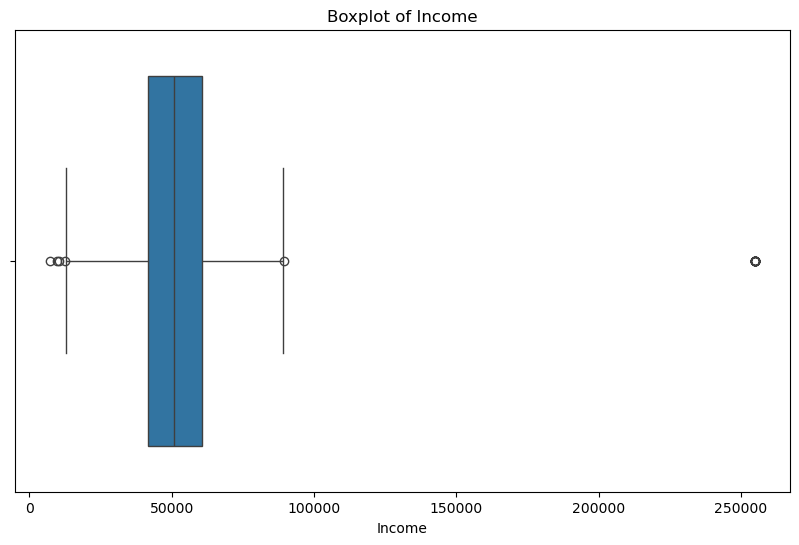

In [49]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['income'])
plt.title('Boxplot of Income')
plt.xlabel('Income')
plt.show()

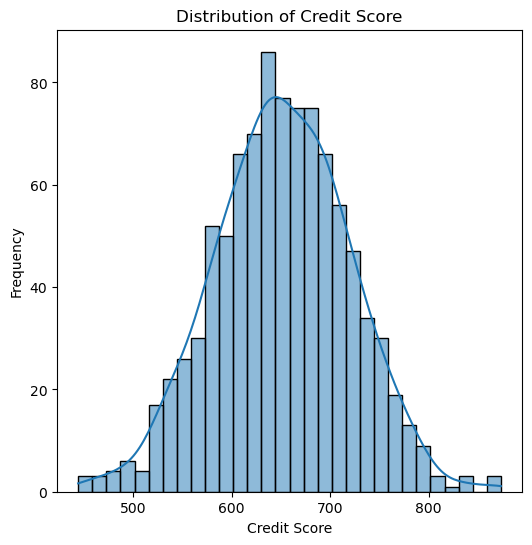

In [50]:
#CHECK THE DISTRIBUTION OF THE CREDIT SCORE COLUMN
plt.figure(figsize=(6, 6))
sns.histplot(data['credit_score'], bins=30, kde=True)
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

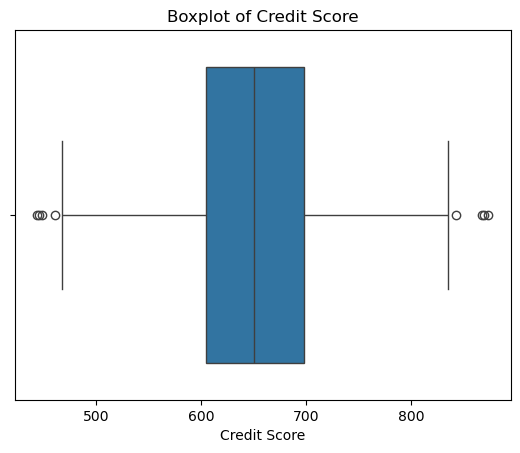

In [51]:
# check the outlier using boxplot for credit score column


# Boxplot for CreditScore column
sns.boxplot(x=data['credit_score'])

plt.title("Boxplot of Credit Score")
plt.xlabel("Credit Score")
plt.show()


In [52]:
# remove the outliers from the credit score column

# Calculate Q1 and Q3
Q1 = data['credit_score'].quantile(0.25)
Q3 = data['credit_score'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove outliers
data_clean = data[(data['credit_score'] >= lower) & (data['credit_score'] <= upper)]

print("Original rows:", len(data))
print("Rows after removing outliers:", len(data_clean))

Original rows: 1000
Rows after removing outliers: 942


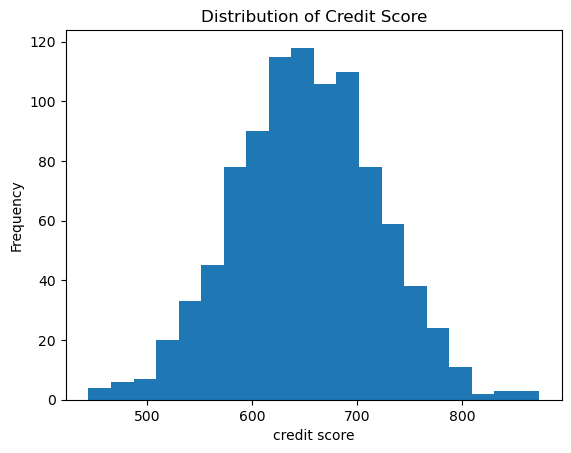

In [53]:
# check the distribution of the credit score column


plt.hist(data['credit_score'], bins=20)
plt.title("Distribution of Credit Score")
plt.xlabel("credit score")
plt.ylabel("Frequency")
plt.show()

In [54]:
# find the mean of credit score column
mean_credit_score = data['credit_score'].mean()
mean_credit_score

np.float64(651.4228367564334)

In [55]:

lower_bound = Q1 -1.5 * IQR
upper_bound = Q3 +1.5 * IQR
data=data[(data['avg_purchase_value']>=lower_bound)&(data['avg_purchase_value'])<=upper_bound]
data

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,50891.366030,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1
...,...,...,...,...,...,...,...,...,...,...,...
995,60,56292.986659,751.728246,26,149.322171,120,93,4,Male,West,0
996,64,36687.617333,556.297594,40,44.289513,172,3,4,Male,South,1
997,62,43438.125495,698.504304,33,132.459634,3,52,2,Male,East,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,Male,West,1


In [56]:
# check unique values in the categorical columns
for col in categorical_cols:
    print(f"Unique values in {col}: {data[col].unique()}")

Unique values in gender: ['Male' 'Female']
Unique values in region: ['South' 'East' 'North' 'West']


In [57]:
# replace the gender column values 0 and 1


data['gender'] = data['gender'].replace({0: 'Male', 1: 'Female'})

print(data.head())

   age        income  credit_score  transactions_month  avg_purchase_value  \
0   56  50891.366030    770.887470                  29           84.828689   
1   69  53051.954538    622.025467                  41          133.943805   
2   46  38654.738821    665.727931                  36          114.993023   
3   32  28666.194356    715.281358                  29          153.875284   
4   60  40301.406736           NaN                  27          115.391031   

   days_since_last_login  tenure_months  num_products  gender region  churn  
0                    143             90             1    Male  South      1  
1                     72             96             4  Female   East      1  
2                    155             88             3    Male  North      1  
3                     76            110             2    Male  South      0  
4                    168             99             2    Male   East      1  


In [58]:
# change only boolean columns into 0 and 1

# Find boolean columns
boolean_cols = data.select_dtypes(include='bool').columns
for col in boolean_cols:
   
    data[col] = data[col].astype(int)

print(data.head())

   age        income  credit_score  transactions_month  avg_purchase_value  \
0   56  50891.366030    770.887470                  29           84.828689   
1   69  53051.954538    622.025467                  41          133.943805   
2   46  38654.738821    665.727931                  36          114.993023   
3   32  28666.194356    715.281358                  29          153.875284   
4   60  40301.406736           NaN                  27          115.391031   

   days_since_last_login  tenure_months  num_products  gender region  churn  
0                    143             90             1    Male  South      1  
1                     72             96             4  Female   East      1  
2                    155             88             3    Male  North      1  
3                     76            110             2    Male  South      0  
4                    168             99             2    Male   East      1  


In [59]:
data.dtypes


age                        int64
income                   float64
credit_score             float64
transactions_month         int64
avg_purchase_value       float64
days_since_last_login      int64
tenure_months              int64
num_products               int64
gender                    object
region                    object
churn                      int64
dtype: object

In [60]:
data.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,50891.366030,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1
